Epoch 1/10


C:\Users\delll\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


111/111 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - loss: 0.0590
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 43ms/step - loss: 0.0012
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 48ms/step - loss: 0.0011
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - loss: 9.7985e-04
Epoch 5/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 9.1000e-04
Epoch 6/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 49ms/step - loss: 8.2900e-04
Epoch 7/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 8.2508e-04
Epoch 8/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - loss: 8.7668e-04
Epoch 9/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - loss: 7.5742e-04
Epoch 10/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 6s 57ms/step - loss: 6.9249e-04
Epoch 1/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 22s 77ms/step - loss: 0.0401
Epoch 2/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - loss: 5.0299e-04
Epoch 3/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - loss: 4.1313e-04
Epoch 4/10
111/111 ━━━━━━━━━━━━━━━━━━━━ 7s 59ms/step - loss: 3.9465e-04
Epoch 5/10
111/

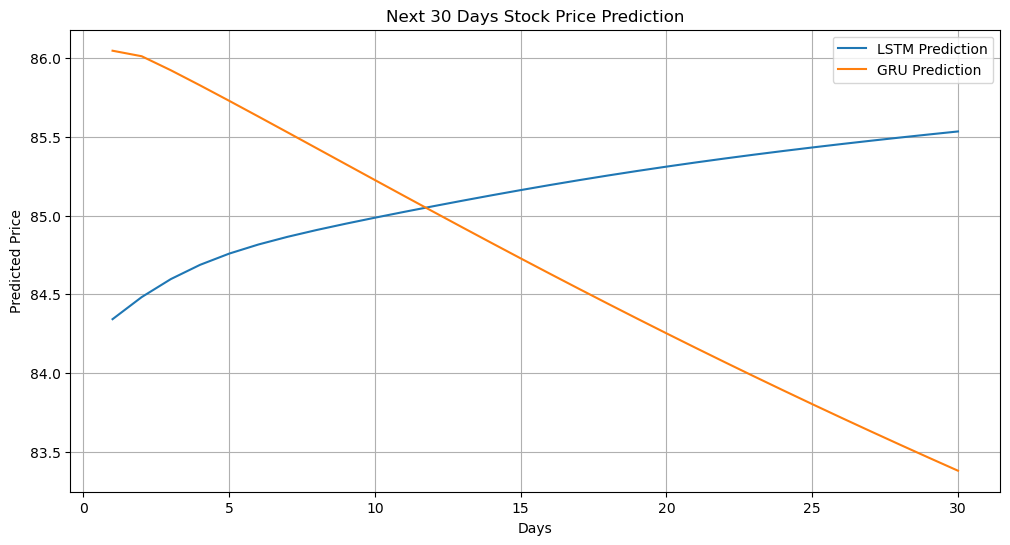

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense

# Load data
df = pd.read_csv('data/AUD_NPRData.csv')  # Replace with your CSV filename
df['Date'] = pd.to_datetime(df['Date'])
df.sort_values('Date', inplace=True)

# Use only the 'Close' column
data = df[['Price']].values

# Scale data
scaler = MinMaxScaler()
data_scaled = scaler.fit_transform(data)

# Create sequences
def create_dataset(data, window_size=60):
    x, y = [], []
    for i in range(window_size, len(data)):
        x.append(data[i-window_size:i, 0])
        y.append(data[i, 0])
    return np.array(x), np.array(y)

window_size = 60
x, y = create_dataset(data_scaled, window_size)
x = np.reshape(x, (x.shape[0], x.shape[1], 1))

# Split into training and testing (optional)
train_size = int(len(x) * 0.9)
x_train, y_train = x[:train_size], y[:train_size]

# Build LSTM model
lstm_model = Sequential([
    LSTM(50, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    LSTM(50),
    Dense(1)
])
lstm_model.compile(optimizer='adam', loss='mean_squared_error')
lstm_model.fit(x_train, y_train, epochs=10, batch_size=32)

# Build GRU model
gru_model = Sequential([
    GRU(50, return_sequences=True, input_shape=(x_train.shape[1], 1)),
    GRU(50),
    Dense(1)
])
gru_model.compile(optimizer='adam', loss='mean_squared_error')
gru_model.fit(x_train, y_train, epochs=10, batch_size=32)

# Predict next 30 days
def predict_next_30(model, last_sequence):
    predictions = []
    current_seq = last_sequence
    for _ in range(30):
        pred = model.predict(current_seq.reshape(1, window_size, 1), verbose=0)
        predictions.append(pred[0, 0])
        current_seq = np.append(current_seq[1:], pred)
    return scaler.inverse_transform(np.array(predictions).reshape(-1, 1))

last_sequence = data_scaled[-window_size:].flatten()
lstm_predictions = predict_next_30(lstm_model, last_sequence)
gru_predictions = predict_next_30(gru_model, last_sequence)
print("lstm_predictions", lstm_predictions)
print("gru_predictions", gru_predictions)
# Plot results
plt.figure(figsize=(12, 6))
plt.plot(np.arange(1, 31), lstm_predictions, label='LSTM Prediction')
plt.plot(np.arange(1, 31), gru_predictions, label='GRU Prediction')
plt.title('Next 30 Days Stock Price Prediction')
plt.xlabel('Days')
plt.ylabel('Predicted Price')
plt.legend()
plt.grid(True)
plt.show()
